# Assignmnent 2 Keras MNIST Classifier

Name: Levi Perry                        ID: 1606009

## Imports and loading data

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import keras
from keras import layers

In [68]:
def scale_type(split):
    return split.astype(np.float32) / 255.0

def flatten(split):
    return split.reshape(-1, 28 * 28)

In [69]:
np.random.seed(1606009)

# Load dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = scale_type(X_train)
X_test = scale_type(X_test)

X_train_flat = flatten(X_train)
X_test_flat = flatten(X_test)

print(X_train_flat.shape, y_train.shape)


(60000, 784) (60000,)


In [70]:
def include_first(split, val_samples=10000):
    return split[:val_samples]

def exclude_first(split, val_samples=10000):
    return split[val_samples:]

In [71]:
# Splitting validation
x_val = include_first(X_train_flat)
y_val = include_first(y_train)
X_train_flat = exclude_first(X_train_flat)
y_train = exclude_first(y_train)

print("Train:", X_train_flat.shape[0], " Val:", x_val.shape[0], " Test:", X_test_flat.shape[0])

Train: 50000  Val: 10000  Test: 10000


## Building the model

In [72]:
def build_model(use_dropout=False, dropout_rate=0.5, num_classes=10):
    model = keras.Sequential([
        layers.Input((784,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(258, activation="relu"),  
    ])
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def fit_model(built_model, x_train, y_train, epochs, batch_size, x_val, y_val):
    return built_model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        verbose=1,
    )

def evaluate_model(built_model, x_test, y_test):
    return built_model.evaluate(x_test, y_test, verbose=0)
    

## Training baseline model

In [73]:
EPOCHS = 20
BATCH_SIZE = 128

model_baseline = build_model()
history_baseline = fit_model(model_baseline, X_train_flat, y_train, 
                             EPOCHS, BATCH_SIZE,
                             x_val, y_val)
test_loss, test_acc = evaluate_model(model_baseline, X_test_flat, y_test)

print(f"Baseline test accuracy: {test_acc:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9259 - loss: 0.2514 - val_accuracy: 0.9635 - val_loss: 0.1237
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9723 - loss: 0.0927 - val_accuracy: 0.9693 - val_loss: 0.0980
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9819 - loss: 0.0583 - val_accuracy: 0.9743 - val_loss: 0.0855
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9874 - loss: 0.0397 - val_accuracy: 0.9741 - val_loss: 0.0839
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9908 - loss: 0.0278 - val_accuracy: 0.9773 - val_loss: 0.0766
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9938 - loss: 0.0203 - val_accuracy: 0.9776 - val_loss: 0.0794
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9937 - loss: 0.0190 - val_accuracy: 0.9788 - val_loss: 0.0873
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9948 - loss: 0.0154 - val_accuracy: 0.

## Training dropout model

In [74]:
model_dropout = build_model(True)
history_dropout = fit_model(model_dropout, X_train_flat, y_train,
                            EPOCHS, BATCH_SIZE,
                            x_val, y_val)
test_loss_do, test_acc_do = evaluate_model(model_dropout, X_test_flat, y_test)

print(f"Dropout test accuracy: {test_acc:.4f}")

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9069 - loss: 0.3150 - val_accuracy: 0.9607 - val_loss: 0.1328
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9639 - loss: 0.1204 - val_accuracy: 0.9729 - val_loss: 0.0907
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9743 - loss: 0.0820 - val_accuracy: 0.9754 - val_loss: 0.0849
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9814 - loss: 0.0596 - val_accuracy: 0.9768 - val_loss: 0.0796
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9856 - loss: 0.0439 - val_accuracy: 0.9777 - val_loss: 0.0779
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9881 - loss: 0.0381 - val_accuracy: 0.9776 - val_loss: 0.0763
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9904 - loss: 0.0282 - val_accuracy: 0.9797 - val_loss: 0.0794
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9923 - loss: 0.0235 - val_accuracy: 0.

## Compare learning curves

In [75]:
def plot_histories(histories, labels, metric="loss"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 8))
    for hist, label in zip(histories, labels):
        axes[0].plot(hist.history[metric], 
                    label=f"{label} train")
        axes[0].plot(hist.history[f"val_{metric}"], 
                    linestyle="--", 
                    label=f"{label} val")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel(metric)
        axes[0].legend()
        axes[0].set_title(f"Training vs validation {metric}")
        axes[0].grid(True, alpha=0.3)
    for hist, label in zip(histories, labels):
        axes[1].plot(hist.history["accuracy"], 
                    label=f"{label} train")
        axes[1].plot(hist.history["val_accuracy"], 
                    linestyle="--", 
                    label=f"{label} val")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

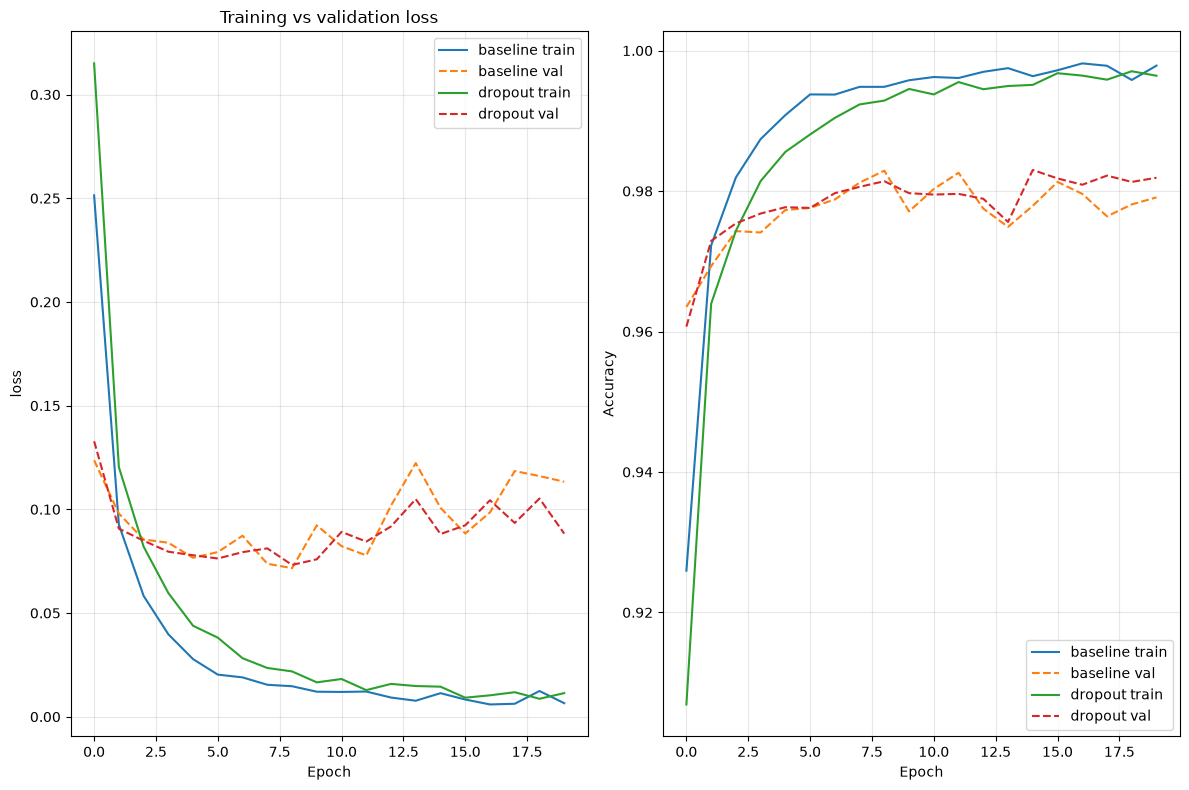

In [76]:
plot_histories([history_baseline, history_dropout], ["baseline", "dropout"])

## Confusion Matrix

In [77]:
def plot_matrix(cm):
    fig, ax = plt.subplots(figsize=(8,7))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("MNIST confusion matrix (dropout model)")
    plt.show()

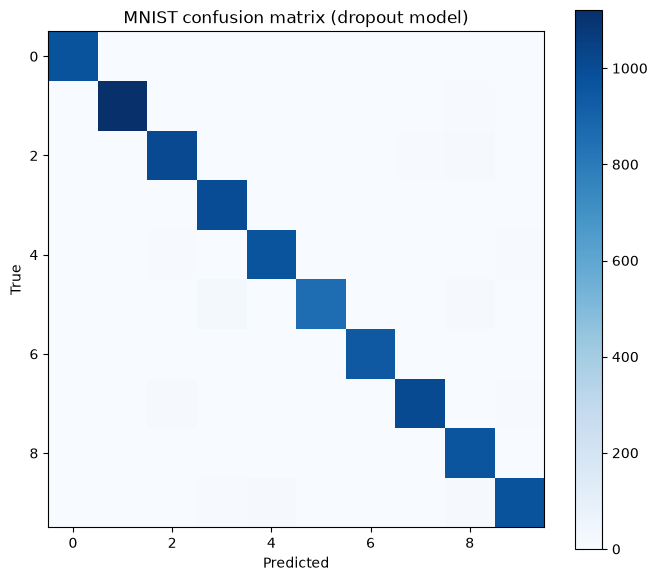

Worst confused pair: 5-3 (20 errors)


In [78]:
y_pred = np.argmax(model_dropout.predict(X_test_flat, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

plot_matrix(cm)

cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
true_i, pred_j = np.unravel_index(np.argmax(cm_off), cm_off.shape)
print(f"Worst confused pair: {true_i}-{pred_j} ({cm_off[true_i, pred_j]} errors)")

## Why sparse categorical cross entropy?

Larger dropout less acurracy and higher loss compared to lower dropout.